<a href="https://colab.research.google.com/github/akpatil4/AI-Cell-Dissertation/blob/main/cpn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install celldetection
!pip install torch

In [9]:
import torch, cv2, celldetection as cd
import os
import matplotlib.pyplot as plt

# Load pre-trained CPN model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = cd.fetch_model('ginoro_CpnResNeXt101UNet-fbe875f1a3e5ce2c', check_hash=True).to(device)
model.eval()

# Load and preprocess image
image_name = 'Image2.png'
image = cv2.imread(image_name)
print(image.dtype, image.shape, (image.min(), image.max()))

# Run model
with torch.no_grad():
    x = cd.to_tensor(image, transpose=True, device=device, dtype=torch.float32)
    x = x / 255  # ensure 0..1 range
    x = x[None]  # add batch dimension: Tensor[3, h, w] -> Tensor[1, 3, h, w]
    y = model(x)



uint8 (889, 1842, 3) (np.uint8(0), np.uint8(255))


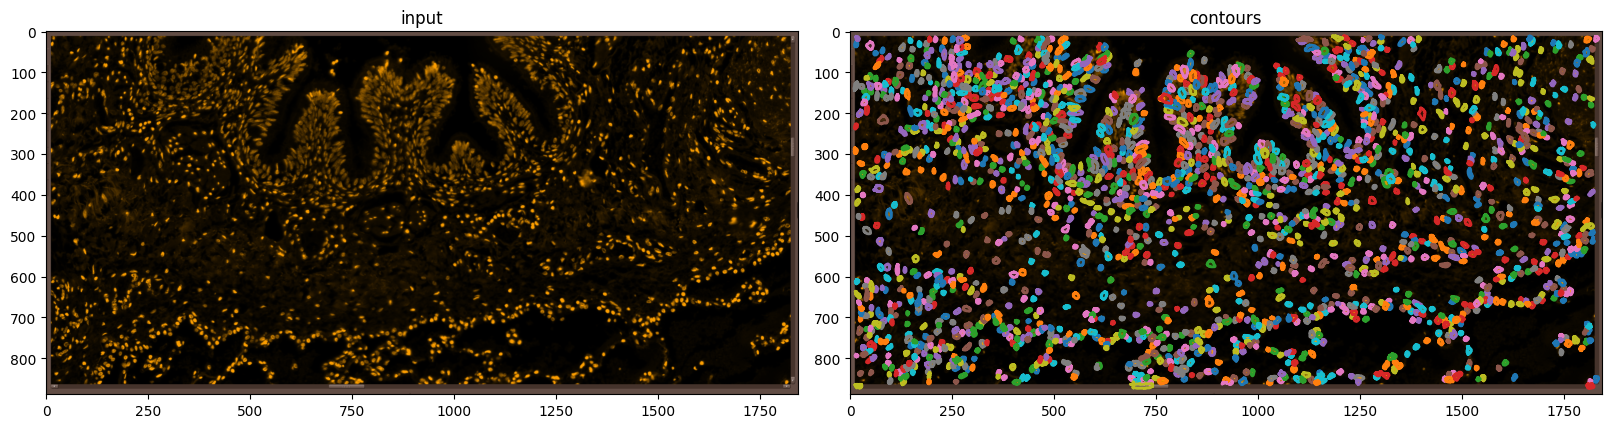

In [10]:
# Show results for each batch item
contours = y['contours']
for n in range(len(x)):
    cd.imshow_row(x[n], x[n], figsize=(16, 9), titles=('input', 'contours'))
    cd.plot_contours(contours[n])
    plt.show()


In [17]:
import numpy as np
import pandas as pd
import cv2

def describe_contours(contour_list, gray_img):
    areas = []

    # Ensure gray_img is 2D (if it's color, convert it)
    if len(gray_img.shape) == 3:
        gray_img = cv2.cvtColor(gray_img, cv2.COLOR_RGB2GRAY)

    for cnt in contour_list:
        # Convert to integer and reshape to OpenCV format (N, 1, 2)
        cnt = np.array(cnt).astype(np.int32).reshape((-1, 1, 2))

        # Calculate Area
        area = cv2.contourArea(cnt)
        areas.append(area)


    areas = np.array(areas)

    print(f"Total structures detected: {len(contour_list)}")
    print(f"\nArea (pixels):")
    print(f"  Total Area: {areas.sum():.2f}")
    print(f"  Mean Area: {areas.mean():.2f}")
    print(f"  Std of Area: {areas.std():.2f}")


# --- ADD THIS AT THE BOTTOM ---

# 1. Get the contours from your CPN output 'y'
# We take index [0] because the model output is usually a list for a batch of images
cpn_contours = y['contours'][0]

# 2. Call the function with your contours and the original image
describe_contours(cpn_contours, image)



Total structures detected: 2107

Area (pixels):
  Total Area: 208548.00
  Mean Area: 98.98
  Std of Area: 42.27
